# Financial Econometrics Project #1  
## Best-Practices Handbook for Time-Series Modeling Challenges

**Name:** Tapiwanashe J. Tapfumaneyi  
**Course:** HASTS 201 / Financial Econometrics  
**Programme:** HDSC
**Reg NO:** R207232K  

---

## Project Aim

This notebook develops a best-practices handbook for handling common problems in financial time-series modeling. The analysis uses stock-market data and shows how each problem can be identified, visualized, diagnosed, and addressed in a practical finance setting.

## Selected Four Challenges

This handbook addresses the following four challenges:

1. **Skewness**  
2. **Sensitivity to Outliers**  
3. **Overfitting**  
4. **Lack of Interpretation**  




##  Setup and Imports

This section imports the required Python libraries. The code is written at a beginner-to-intermediate level while still following professional financial-econometrics practice.


In [1]:
# ============================================================
# SETUP AND IMPORTS
# ============================================================

# If yfinance is not installed on your computer, run this once:
# !pip install yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats
from scipy.stats import jarque_bera, shapiro, zscore

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True


## 1. Data Import and Preparation

The notebook uses daily adjusted closing prices from Yahoo Finance. Apple is used as the main stock because it is liquid, widely followed, and sensitive to broad market conditions. Additional market variables are included later for interpretation and prediction examples.

The sample period is **1 January 2018 to 31 December 2025**.

**Data access note:** This notebook requires internet access to download market data from Yahoo Finance through `yfinance`. If the download fails, rerun the data-import cell when the internet connection is stable.


In [2]:
# ============================================================
# SECTION 1 — DATA IMPORT AND PREPARATION
# ============================================================

TICKERS = ["AAPL", "MSFT", "SPY", "^VIX"]
START = "2018-01-01"
END = "2026-01-01"  # yfinance treats the end date as exclusive

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)

# Extract adjusted close prices. yfinance stores adjusted prices under "Close" when auto_adjust=True.
prices = raw["Close"].copy()
prices = prices.dropna()

# Rename VIX column for cleaner display
prices = prices.rename(columns={"^VIX": "VIX"})

# Compute daily log returns for stocks and percentage change for VIX
returns = np.log(prices[["AAPL", "MSFT", "SPY"]] / prices[["AAPL", "MSFT", "SPY"]].shift(1))
returns["VIX_change"] = prices["VIX"].pct_change()
returns = returns.dropna()

print("Price data shape:", prices.shape)
print("Return data shape:", returns.shape)
display(prices.head())
display(returns.head())


Price data shape: (2011, 4)
Return data shape: (2010, 4)


Ticker,AAPL,MSFT,SPY,VIX
Date,,,,
2018-01-02,40.304165,78.870361,236.562164,9.770000
2018-01-03,40.297157,79.237419,238.058456,9.150000
2018-01-04,40.484341,79.934814,239.061844,9.220000
2018-01-05,40.945271,80.925842,240.654892,9.220000
2018-01-08,40.793186,81.008415,241.095047,9.520000


Ticker,AAPL,MSFT,SPY,VIX_change
Date,,,,
2018-01-03,-0.000174,0.004643,0.006305,-0.063460
2018-01-04,0.004634,0.008763,0.004206,0.007650
2018-01-05,0.011321,0.012322,0.006642,0.000000
2018-01-08,-0.003721,0.001020,0.001827,0.032538
2018-01-09,-0.000115,-0.000679,0.002261,0.058823


### Data Preparation Interpretation

The analysis uses daily market data because volatility modeling and derivative-risk decisions are usually sensitive to daily movements. Log returns are used because they are standard in finance and can be added across time. The same return dataset is used across the demonstrations and diagrams so that the numerical examples and visuals remain consistent.


# Challenge 1: Skewness

## 1.1 Definition

Skewness measures the asymmetry of a return distribution around its mean. For a return series $r_t$, sample skewness is:

$$
\text{Skewness} = \frac{\frac{1}{n}\sum_{t=1}^{n}(r_t-\bar r)^3}{\left(\frac{1}{n}\sum_{t=1}^{n}(r_t-\bar r)^2\right)^{3/2}}
$$

Where:

- $r_t$ is the daily return at time $t$,
- $\bar r$ is the average return,
- $n$ is the number of observations.

A distribution is **negatively skewed** when large losses are more extreme than large gains. It is **positively skewed** when large gains are more extreme than large losses.

## 1.2 Description

Skewness matters in financial econometrics because stock returns are often not perfectly symmetric. Financial return distributions often show asymmetry and excess kurtosis, so normal-distribution assumptions may underestimate tail risk (Tsay). If a model assumes normality while returns are strongly skewed, the model may underestimate the probability of extreme losses or gains.


## 1.3 Demonstration: Measuring Skewness in AAPL Returns

The code below calculates the mean, standard deviation, skewness, kurtosis, and normality tests for Apple daily returns.


In [3]:
# ============================================================
# CHALLENGE 1 — SKEWNESS DEMONSTRATION
# ============================================================

aapl_returns = returns["AAPL"].copy()

skew_stats = pd.DataFrame({
    "Statistic": [
        "Mean daily return",
        "Standard deviation",
        "Skewness",
        "Excess kurtosis",
        "Jarque-Bera p-value",
        "Shapiro-Wilk p-value"
    ],
    "Value": [
        aapl_returns.mean(),
        aapl_returns.std(),
        stats.skew(aapl_returns),
        stats.kurtosis(aapl_returns, fisher=True),
        jarque_bera(aapl_returns).pvalue,
        shapiro(aapl_returns.sample(min(5000, len(aapl_returns)), random_state=42)).pvalue
    ]
})

display(skew_stats)


,Statistic,Value
0,Mean daily return,0.000949
1,Standard deviation,0.019376
2,Skewness,-0.084951
3,Excess kurtosis,6.202778
4,Jarque-Bera p-value,0.000000
5,Shapiro-Wilk p-value,0.000000


## 1.4 Diagram: Distribution of AAPL Returns

The histogram compares the actual distribution of Apple returns with a normal distribution using the same mean and standard deviation.


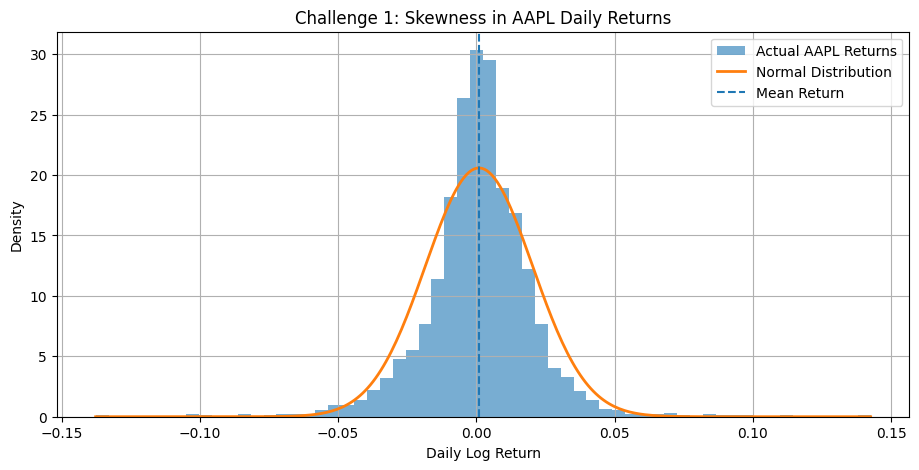

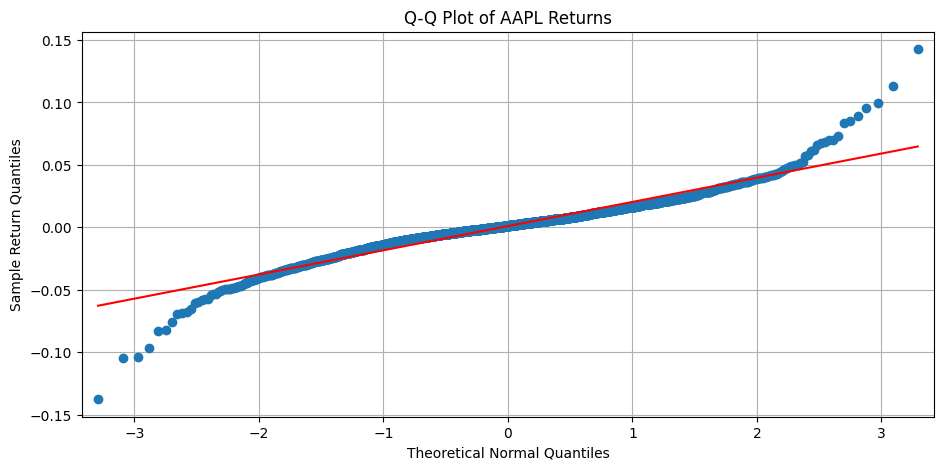

In [4]:
# ============================================================
# CHALLENGE 1 — SKEWNESS DIAGRAM
# ============================================================

mu = aapl_returns.mean()
sigma = aapl_returns.std()

x = np.linspace(aapl_returns.min(), aapl_returns.max(), 300)
normal_curve = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(11, 5))
plt.hist(aapl_returns, bins=60, density=True, alpha=0.6, label="Actual AAPL Returns")
plt.plot(x, normal_curve, linewidth=2, label="Normal Distribution")
plt.axvline(mu, linestyle="--", linewidth=1.5, label="Mean Return")
plt.title("Challenge 1: Skewness in AAPL Daily Returns")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

# Q-Q plot for visual normality checking
sm.qqplot(aapl_returns, line="s")
plt.title("Q-Q Plot of AAPL Returns")
plt.xlabel("Theoretical Normal Quantiles")
plt.ylabel("Sample Return Quantiles")
plt.show()


### Diagram Interpretation: Skewness and Non-Normality in AAPL Returns

The first diagram shows the distribution of AAPL daily log returns. Most of the returns are concentrated very close to zero, meaning that on most trading days AAPL experienced small positive or negative movements. However, the bars do not perfectly follow the orange normal-distribution curve. The actual returns appear more sharply concentrated around the center and have extreme observations in both tails.

The left tail extends to around -0.13, while the right tail extends to around +0.14. This shows that AAPL experienced some unusually large losses and gains during the sample period. Because the tails are heavier than the normal curve suggests, a normal-distribution assumption may underestimate the probability of extreme market movements.

The second diagram, the Q-Q plot, confirms this problem more clearly. In the middle of the plot, the points are close to the red line, meaning normality is a reasonable approximation for ordinary daily returns. However, at both ends of the plot, the points move away from the red line. The lower-left tail falls below the line and the upper-right tail rises above the line, showing that extreme returns are larger than what a normal distribution would predict.

This matters in financial econometrics because volatility models that assume normal returns may underestimate tail risk. For traders and risk managers, this can lead to inaccurate Value-at-Risk, Expected Shortfall, option pricing, and hedging decisions. Therefore, AAPL returns should be modeled with methods that recognize skewness, heavy tails, and non-normal behavior rather than relying only on the normal-distribution assumption.

## 1.5 Diagnosis

Skewness can be diagnosed using both numerical and visual methods:

- A skewness value far from zero suggests asymmetry.
- A Jarque-Bera p-value below 0.05 suggests the distribution is not normal.
- A Q-Q plot with tail points far from the straight line suggests non-normal tails.

## 1.6 Damage

Skewness can damage financial decisions because symmetric models may underestimate downside risk. For a derivatives desk, this can lead to option mispricing, weak hedging, and poor estimation of tail losses.

## 1.7 Directions

To reduce the damage caused by skewness, analysts should follow risk-management practice that allows for asymmetric volatility and non-normal return behavior (Engle; Tsay):

- use log returns rather than raw price changes;
- report downside risk measures such as Value at Risk and Expected Shortfall;
- consider models that allow asymmetric volatility responses, such as GJR-GARCH or EGARCH;
- use stress testing instead of relying only on normal-distribution assumptions.


# Challenge 2: Sensitivity to Outliers

## 2.1 Definition

An outlier is an observation that lies unusually far from the main body of the data. In return data, a common rule is to classify an observation as an outlier if:

$$
|z_t| = \left|\frac{r_t - \bar r}{s}\right| > 3
$$

Where:

- $z_t$ is the z-score of the return,
- $r_t$ is the observed return,
- $\bar r$ is the sample mean return,
- $s$ is the sample standard deviation.

## 2.2 Description

Financial returns often contain extreme observations caused by crashes, earnings shocks, policy announcements, or panic buying and selling. These observations can strongly affect averages, variances, correlations, and regression estimates, which is why financial time-series analysis normally requires diagnostic checking before model use (Zivot and Wang).


## 2.3 Demonstration: Identifying Outliers in AAPL Returns

The code below identifies extreme Apple return days using the absolute z-score rule.


In [5]:
# ============================================================
# CHALLENGE 2 — OUTLIER DEMONSTRATION
# ============================================================

outlier_table = pd.DataFrame({
    "AAPL_Return": aapl_returns,
    "Z_Score": zscore(aapl_returns)
})

outliers = outlier_table[outlier_table["Z_Score"].abs() > 3].copy()
outliers = outliers.sort_values("AAPL_Return")

print("Number of observations:", len(outlier_table))
print("Number of outliers using |z| > 3:", len(outliers))
print("Percentage of observations classified as outliers:", round(100 * len(outliers) / len(outlier_table), 2), "%")

display(outliers.head(10))
display(outliers.tail(10))


Number of observations: 2010
Number of outliers using |z| > 3: 31
Percentage of observations classified as outliers: 1.54 %


,AAPL_Return,Z_Score
Date,,
2020-03-16,-0.137708,-7.158101
2019-01-03,-0.104924,-5.465652
2020-03-12,-0.103978,-5.416801
2025-04-03,-0.097013,-5.057254
2020-09-03,-0.083448,-4.356936
2020-03-09,-0.082395,-4.302609
2025-04-04,-0.075680,-3.955951
2020-09-08,-0.069666,-3.645481
2018-11-02,-0.068633,-3.592143


,AAPL_Return,Z_Score
Date,,
2020-03-10,0.069546,3.541291
2024-06-11,0.070131,3.571493
2022-10-28,0.072835,3.711049
2020-04-06,0.083640,4.268877
2022-11-10,0.085237,4.351289
2020-03-02,0.089018,4.546519
2020-03-24,0.095606,4.886593
2020-07-31,0.099563,5.090903
2020-03-13,0.113158,5.792694


## 2.4 Diagram: Outliers in AAPL Returns

The chart below marks extreme return days on the time series of Apple daily returns.


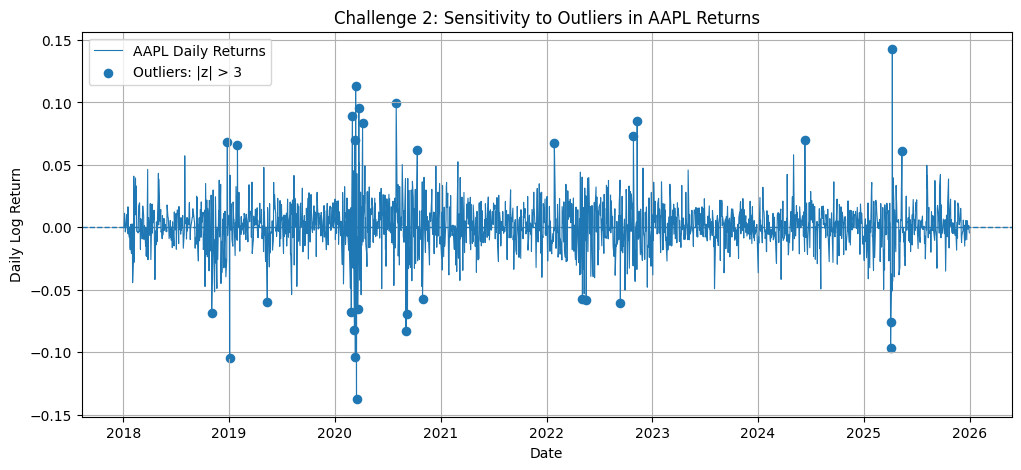

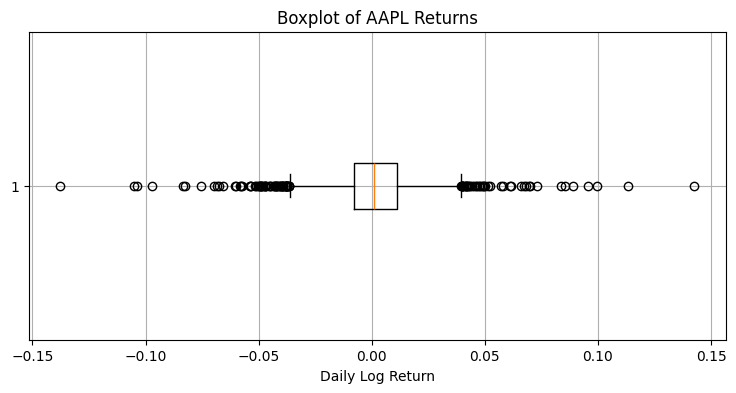

In [6]:
# ============================================================
# CHALLENGE 2 — OUTLIER DIAGRAM
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(aapl_returns.index, aapl_returns, linewidth=0.8, label="AAPL Daily Returns")
plt.scatter(outliers.index, outliers["AAPL_Return"], s=35, label="Outliers: |z| > 3")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Challenge 2: Sensitivity to Outliers in AAPL Returns")
plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.boxplot(aapl_returns, vert=False)
plt.title("Boxplot of AAPL Returns")
plt.xlabel("Daily Log Return")
plt.show()


### Diagram Interpretation: Sensitivity to Outliers in AAPL Returns

The first diagram shows AAPL daily log returns from 2018 to 2026. Most daily returns are close to zero, which means that AAPL normally experienced small daily price movements. However, several observations are far away from the normal range. These points are marked as outliers where the return is greater than three standard deviations from the mean.

The largest negative outliers appear around 2020, where AAPL returns fall close to -0.14. This period reflects extreme market stress, where sudden shocks caused much larger losses than normal trading days. There are also large positive outliers, including one close to +0.14 around 2025. These extreme movements show that AAPL returns are not stable every day and can suddenly move far from the average.

The second diagram, the boxplot, confirms the presence of outliers. Most returns are concentrated inside the box near zero, but many points appear outside the whiskers on both the left and right sides. The left-side outliers show unusually large losses, while the right-side outliers show unusually large gains.

This matters because outliers can strongly affect financial models. They can increase the estimated standard deviation, distort volatility forecasts, affect regression coefficients, and make risk measures less reliable. In trading and risk management, ignoring outliers may lead to wrong conclusions about normal market risk and extreme loss exposure.

Therefore, the analyst should not simply remove these observations without investigation. A better approach is to identify the events behind the extreme returns, compare results before and after winsorization, and use robust risk measures such as Historical VaR, Expected Shortfall, or models that allow for heavy tails.

## 2.5 Diagnosis

Outlier sensitivity can be diagnosed by:

- checking whether many observations have $|z| > 3$;
- using boxplots to identify extreme points;
- comparing model results before and after winsorizing or removing extreme observations;
- investigating whether extreme observations occur during known crisis periods.

The next code cell compares original returns with winsorized returns.


In [7]:
# ============================================================
# CHALLENGE 2 — OUTLIER DIAGNOSIS THROUGH WINSORIZATION
# ============================================================

lower_cap = aapl_returns.quantile(0.01)
upper_cap = aapl_returns.quantile(0.99)

aapl_winsorized = aapl_returns.clip(lower=lower_cap, upper=upper_cap)

comparison = pd.DataFrame({
    "Original Returns": [
        aapl_returns.mean(),
        aapl_returns.std(),
        stats.skew(aapl_returns),
        stats.kurtosis(aapl_returns, fisher=True)
    ],
    "Winsorized Returns": [
        aapl_winsorized.mean(),
        aapl_winsorized.std(),
        stats.skew(aapl_winsorized),
        stats.kurtosis(aapl_winsorized, fisher=True)
    ]
}, index=["Mean", "Standard Deviation", "Skewness", "Excess Kurtosis"])

display(comparison)


,Original Returns,Winsorized Returns
Mean,0.000949,0.000909
Standard Deviation,0.019376,0.017481
Skewness,-0.084951,-0.194814
Excess Kurtosis,6.202778,0.959201


## 2.6 Damage

Outliers can damage financial models because they can exaggerate volatility, distort correlations, and make regression coefficients unstable. For a trading desk, this may lead to excessive margin requirements, poor hedge ratios, or wrong risk limits.

## 2.7 Directions

To manage outlier sensitivity, analysts should:

- investigate the economic reason behind extreme observations;
- compare results with and without extreme values;
- use robust statistics such as median and interquartile range;
- use winsorization carefully when the goal is to reduce extreme influence;
- avoid deleting outliers automatically, because extreme events may contain important risk information.


# Challenge 3: Overfitting

## 3.1 Definition

Overfitting occurs when a model captures random noise in the training data instead of the true underlying relationship. A simple way to identify overfitting is when:

$$
R^2_{\text{train}} \gg R^2_{\text{test}}
$$

or when:

$$
\text{MSE}_{\text{test}} \gg \text{MSE}_{\text{train}}
$$

Where:

- $R^2_{\text{train}}$ is model fit on training data,
- $R^2_{\text{test}}$ is model fit on unseen test data,
- MSE is mean squared error.

## 3.2 Description

Overfitting is dangerous in financial modeling because markets change over time. A model may appear successful on historical data but fail when used for live trading, hedging, or risk management; this is why out-of-sample testing is essential in financial model evaluation (Zivot and Wang).


## 3.3 Demonstration: Comparing a Simple Model and an Overfit Model

The goal is to predict next-day AAPL returns. A simple model uses a few meaningful predictors. An overfit model uses many lagged variables, which can memorize noise.


In [8]:
# ============================================================
# CHALLENGE 3 — OVERFITTING DEMONSTRATION
# ============================================================

model_data = returns.copy()
model_data["AAPL_next"] = model_data["AAPL"].shift(-1)

# Create many lagged AAPL returns to intentionally increase model complexity
for lag in range(1, 21):
    model_data[f"AAPL_lag_{lag}"] = model_data["AAPL"].shift(lag)

model_data = model_data.dropna()

# Simple predictors: broad market, sector-related stock, and volatility change
simple_features = ["SPY", "MSFT", "VIX_change"]

# Complex predictors: simple predictors plus many lagged AAPL returns
complex_features = simple_features + [f"AAPL_lag_{lag}" for lag in range(1, 21)]

y = model_data["AAPL_next"]
X_simple = model_data[simple_features]
X_complex = model_data[complex_features]

# Time-based split: first 80% training, last 20% testing
split_point = int(len(model_data) * 0.80)

X_simple_train, X_simple_test = X_simple.iloc[:split_point], X_simple.iloc[split_point:]
X_complex_train, X_complex_test = X_complex.iloc[:split_point], X_complex.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

simple_model = LinearRegression()
complex_model = LinearRegression()

simple_model.fit(X_simple_train, y_train)
complex_model.fit(X_complex_train, y_train)

simple_train_pred = simple_model.predict(X_simple_train)
simple_test_pred = simple_model.predict(X_simple_test)
complex_train_pred = complex_model.predict(X_complex_train)
complex_test_pred = complex_model.predict(X_complex_test)

performance = pd.DataFrame({
    "Model": ["Simple model", "Complex lag model"],
    "Train R2": [
        r2_score(y_train, simple_train_pred),
        r2_score(y_train, complex_train_pred)
    ],
    "Test R2": [
        r2_score(y_test, simple_test_pred),
        r2_score(y_test, complex_test_pred)
    ],
    "Train MSE": [
        mean_squared_error(y_train, simple_train_pred),
        mean_squared_error(y_train, complex_train_pred)
    ],
    "Test MSE": [
        mean_squared_error(y_test, simple_test_pred),
        mean_squared_error(y_test, complex_test_pred)
    ]
})

display(performance)


,Model,Train R2,Test R2,Train MSE,Test MSE
0,Simple model,0.018927,-0.002874,0.000382,0.000334
1,Complex lag model,0.048880,-0.047228,0.000371,0.000348


## 3.4 Diagram: Training Performance vs Testing Performance

The bar chart compares how well each model performs in-sample and out-of-sample.


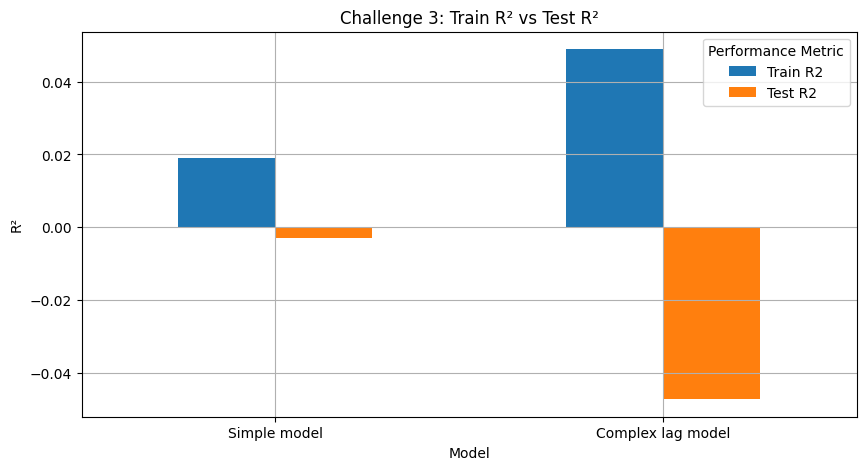

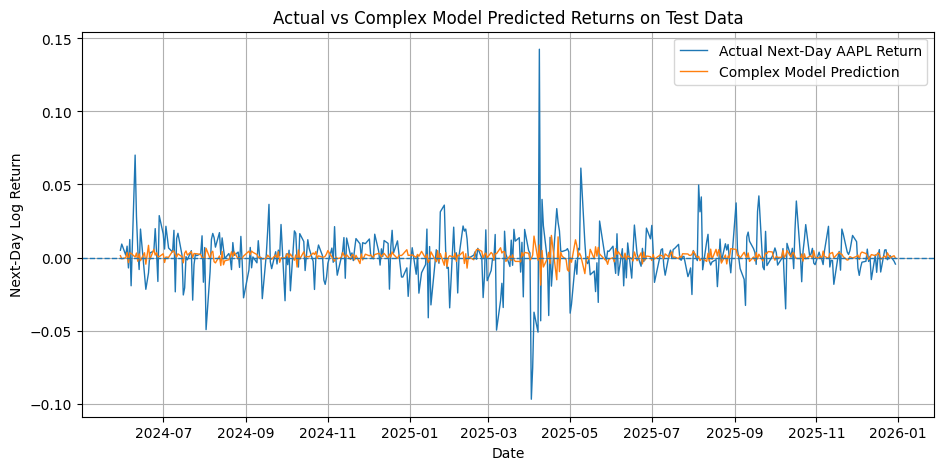

In [9]:
# ============================================================
# CHALLENGE 3 — OVERFITTING DIAGRAM
# ============================================================

plot_data = performance.set_index("Model")[["Train R2", "Test R2"]]

plot_data.plot(kind="bar", figsize=(10, 5))
plt.title("Challenge 3: Train R² vs Test R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.legend(title="Performance Metric")
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(y_test.index, y_test.values, linewidth=1, label="Actual Next-Day AAPL Return")
plt.plot(y_test.index, complex_test_pred, linewidth=1, label="Complex Model Prediction")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Actual vs Complex Model Predicted Returns on Test Data")
plt.xlabel("Date")
plt.ylabel("Next-Day Log Return")
plt.legend()
plt.show()


### Diagram Interpretation: Overfitting in AAPL Return Prediction

The first diagram compares the training and testing performance of two models: a simple model and a complex lag model. The simple model has a small positive training \(R^2\) of about 0.02, while its test \(R^2\) is slightly below zero. This means the simple model explains only a small part of the variation in the training data and performs poorly on unseen data.

The complex lag model performs better in-sample, with a higher training \(R^2\) of about 0.05. However, its test \(R^2\) is much worse, falling to about -0.05. This is a strong sign of overfitting. The model appears to fit the historical training data more closely, but that extra complexity does not improve forecasting performance. Instead, it makes the model less reliable when applied to new observations.

The second diagram confirms this problem. The blue line, which shows the actual next-day AAPL returns, is highly volatile and includes several sharp positive and negative movements. In contrast, the orange line, which shows the complex model’s predicted returns, stays close to zero for most of the period and fails to capture the large swings in the actual data.

This matters because a model that looks better in-sample may create false confidence for traders and risk managers. In real financial markets, a model must generalize well to future data rather than simply memorizing patterns in the past. Therefore, this diagram shows that increasing model complexity without improving out-of-sample performance can damage forecasting quality. A better approach is to prefer simpler models, use time-based train-test validation, and apply regularization or model selection techniques to reduce overfitting.

## 3.5 Diagnosis

Overfitting is diagnosed when the model performs much better on training data than on test data. In finance, a very high training result is not enough. The model must also work on unseen data.

## 3.6 Damage

Overfitting can damage financial decision-making by creating false confidence. A trader may believe a strategy is profitable because it worked in historical data, but it may fail in live markets. For derivative pricing and hedging, overfitting can produce unreliable hedge ratios and unstable risk forecasts.

## 3.7 Directions

To reduce overfitting, analysts should use model-validation procedures and avoid unnecessary complexity unless it improves out-of-sample performance (Zivot and Wang):

- use a time-based train-test split instead of random splitting;
- compare training and testing performance;
- keep models as simple as possible;
- apply regularization methods such as Ridge or Lasso;
- use rolling-window validation for time-series models;
- avoid adding predictors that have no clear economic meaning.


# Challenge 4: Lack of Interpretation

## 4.1 Definition

Lack of interpretation occurs when a model produces numerical outputs, but the analyst cannot clearly explain what the results mean for financial decisions. In a linear model:

$$
r_{AAPL,t+1} = \alpha + \beta_1 r_{SPY,t} + \beta_2 r_{MSFT,t} + \beta_3 \Delta VIX_t + \varepsilon_t
$$

Each coefficient should have a clear meaning:

$$
\beta_j = \frac{\partial r_{AAPL,t+1}}{\partial x_{j,t}}
$$

This means $\beta_j$ measures the expected change in next-day Apple return for a one-unit change in predictor $x_j$, holding other predictors constant.

## 4.2 Description

A model that cannot be explained is difficult to trust. In financial econometrics, interpretation matters because traders and risk managers must understand which factors drive portfolio risk and which actions follow from the results; this is especially important for derivative pricing, hedging, and risk-control decisions (Hull).


## 4.3 Demonstration: Interpretable Regression for AAPL Returns

This section estimates an interpretable regression model using market return, Microsoft return, and VIX change as predictors.


In [10]:
# ============================================================
# CHALLENGE 4 — INTERPRETATION DEMONSTRATION
# ============================================================

interpret_data = model_data[["AAPL_next", "SPY", "MSFT", "VIX_change"]].copy()

Y = interpret_data["AAPL_next"]
X = interpret_data[["SPY", "MSFT", "VIX_change"]]
X_const = sm.add_constant(X)

interpretable_model = sm.OLS(Y, X_const).fit()
print(interpretable_model.summary())

coef_table = pd.DataFrame({
    "Coefficient": interpretable_model.params,
    "P-value": interpretable_model.pvalues,
    "Interpretation": [
        "Average next-day AAPL return when all predictors are zero.",
        "Effect of broad market movement on next-day AAPL return.",
        "Effect of MSFT movement on next-day AAPL return.",
        "Effect of market fear/volatility change on next-day AAPL return."
    ]
})

display(coef_table)


                            OLS Regression Results                            
Dep. Variable:              AAPL_next   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     10.46
Date:                Fri, 08 May 2026   Prob (F-statistic):           7.97e-07
Time:                        15:22:42   Log-Likelihood:                 5029.9
No. Observations:                1989   AIC:                        -1.005e+04
Df Residuals:                    1985   BIC:                        -1.003e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.000      2.678      0.0

,Coefficient,P-value,Interpretation
const,0.001167,0.007462,Average next-day AAPL return when all predicto...
SPY,-0.267721,0.000164,Effect of broad market movement on next-day AA...
MSFT,0.001796,0.965347,Effect of MSFT movement on next-day AAPL return.
VIX_change,-0.016898,0.017232,Effect of market fear/volatility change on nex...


## 4.4 Diagram: Factor Importance Using Standardized Coefficients

Because the predictors are measured on different scales, standardized coefficients make their relative importance easier to compare.


,Factor,Standardized_Coefficient,Absolute_Importance
0,SPY,-0.169779,0.169779
2,VIX_change,-0.076855,0.076855
1,MSFT,0.001653,0.001653


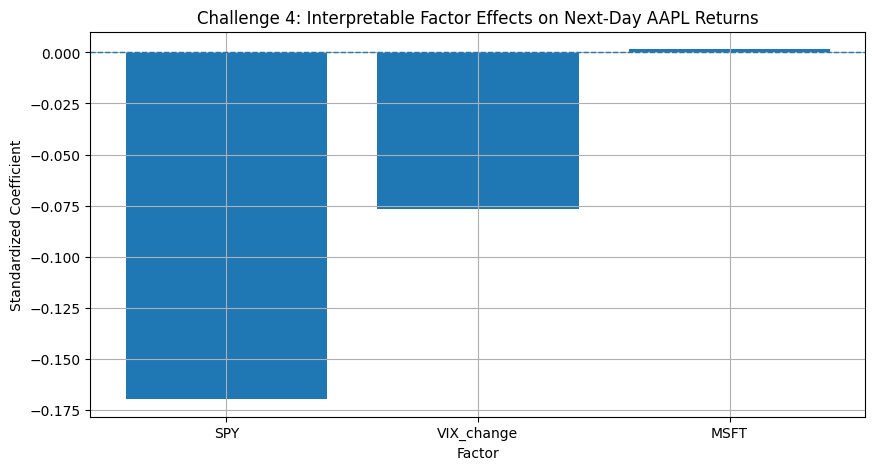

In [11]:
# ============================================================
# CHALLENGE 4 — INTERPRETATION DIAGRAM
# ============================================================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(Y.values.reshape(-1, 1)).ravel()

standardized_model = LinearRegression()
standardized_model.fit(X_scaled, y_scaled)

importance = pd.DataFrame({
    "Factor": X.columns,
    "Standardized_Coefficient": standardized_model.coef_,
    "Absolute_Importance": np.abs(standardized_model.coef_)
}).sort_values("Absolute_Importance", ascending=False)

display(importance)

plt.figure(figsize=(10, 5))
plt.bar(importance["Factor"], importance["Standardized_Coefficient"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Challenge 4: Interpretable Factor Effects on Next-Day AAPL Returns")
plt.xlabel("Factor")
plt.ylabel("Standardized Coefficient")
plt.show()


### Diagram Interpretation: Interpretable Factor Effects on Next-Day AAPL Returns

The table and bar chart show the standardized coefficients of the three explanatory factors: SPY, VIX_change, and MSFT. Because the coefficients are standardized, they can be compared directly to see which factor has the strongest influence on next-day AAPL returns.

The diagram shows that **SPY** has the largest effect, with a standardized coefficient of about **-0.1698**. This means SPY is the most important factor in the model, and its relationship with next-day AAPL returns is negative over the sample used in this analysis. The second most important factor is **VIX_change**, with a coefficient of about **-0.0769**, which also has a negative effect. This suggests that increases in market volatility are associated with lower next-day AAPL returns. In contrast, **MSFT** has a very small positive coefficient of about **0.0017**, meaning its effect is almost negligible compared with the other two factors.

This diagram is important because it makes the model easier to interpret in financial terms. Instead of producing a prediction without explanation, it shows clearly which variables are driving the result and in what direction. A trader or risk manager can immediately see that broad market movement and volatility matter more for predicting AAPL than the MSFT factor in this model.

Without this kind of interpretation, the model would be difficult to trust or apply in practice. By presenting the factor effects visually, the analysis becomes more transparent and more useful for decision-making, portfolio monitoring, and risk management.

## 4.5 Diagnosis

Lack of interpretation can be diagnosed by asking:

- Can each predictor be explained in simple financial language?
- Are the signs of the coefficients economically reasonable?
- Are the most important factors clearly identified?
- Can the model output lead to a practical trading, hedging, or risk-management action?

## 4.6 Damage

Lack of interpretation damages financial decision-making because users may not know why the model recommends a position or hedge. This can reduce trust, increase model-risk concerns, and make it difficult to defend decisions to managers or clients.

## 4.7 Directions

To improve interpretation, analysts should connect statistical outputs to economically meaningful variables and practical risk-management actions (Hull):

- use variables with clear economic meaning;
- provide coefficient tables with plain-English explanations;
- use standardized coefficients to compare factor importance;
- avoid unnecessary technical language in non-technical reports;
- connect every result to a recommended financial action.


# Technical Report

The four challenges are supported by code, outputs, diagrams, and interpretations. These diagnostics are supported by standard financial-econometrics practice, where model assumptions, distributional behavior, and out-of-sample reliability must be checked before models are used for trading or risk management (Tsay; Zivot and Wang).

## Technical Summary

| Challenge | Main Diagnostic Tool | Main Risk | Recommended Response |
|---|---|---|---|
| Skewness | Skewness statistic, Jarque-Bera test, Q-Q plot | Underestimation of tail risk | Use downside risk measures and asymmetric volatility models |
| Sensitivity to Outliers | Z-scores, boxplots, winsorization comparison | Distorted volatility and unstable estimates | Investigate outliers and compare robust results |
| Overfitting | Train-test comparison | False confidence from historical fit | Use time-based testing and simpler models |
| Lack of Interpretation | Coefficient table and standardized coefficients | Results cannot support clear decisions | Use explainable variables and plain-language interpretation |

The technical evidence shows that financial time-series models must be tested carefully before being used for derivative pricing, trading, or risk management.


# Non-Technical Report

Financial-market data can be difficult to model because returns do not always behave smoothly. Apple returns show signs of asymmetry, extreme movements, and changing behavior over time. These features mean that a model that looks correct on paper may still produce weak decisions if it ignores unusual market conditions. For a derivatives desk, this matters because option pricing, hedging, and risk limits depend on realistic assumptions about return behavior and volatility (Hull; Tsay).

The main recommendation is that traders and risk managers should not rely on one model or one statistic. They should check whether the data contains extreme movements, whether the model performs well on new data, and whether the results can be clearly explained. A model should only be used if its results lead to a practical action, such as adjusting hedge sizes, changing risk limits, or reviewing portfolio exposure.

The most important factors affecting the portfolio in this notebook are broad market movement, related technology-stock movement, and changes in market fear. These factors should be monitored because they influence Apple’s short-term return behavior and can affect option prices, hedging decisions, and risk exposure.


# Works Cited

Engle, Robert F. “Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation.” *Econometrica*, vol. 50, no. 4, 1982, pp. 987–1007.

Hull, John C. *Options, Futures, and Other Derivatives*. Pearson, 2022.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., Wiley, 2010.

Yahoo Finance. “Apple Inc. (AAPL), Microsoft Corporation (MSFT), SPDR S&P 500 ETF Trust (SPY), and CBOE Volatility Index (^VIX) Historical Data.” *Yahoo Finance*, accessed 8 May 2026.

Zivot, Eric, and Jiahui Wang. *Modeling Financial Time Series with S-PLUS*. 2nd ed., Springer, 2006.
